In [3]:
import sys
import argparse
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import numpy as np
import pandas as pd

import csv
import gzip

import scipy.io
import numpy as np 

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.pyplot import rc_context
import anndata
import torch

# --- MATPLOTLIB SETTINGS ---
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc
rc_params = {
    "font.family": "sans-serif", # "text.usetex": True,
    "font.serif" : ['Arial'], # "font.size" : 6,
    "font.weight" : "normal",
    'xtick.labelsize' : 5,
    'ytick.labelsize' : 5,
    'legend.fontsize' : 5,
    'axes.labelsize' : 6,
    'axes.linewidth': 0.8,
    'lines.linewidth' : 1,
    'axes.titlesize' : 7 # figure.titlesize
}
matplotlib.rcParams.update(rc_params)
margins = {  #     vvv margin in inches
    "left"   :     0.2,
    'right' : 1.0,
    'bottom' : 0.15
}



In [4]:

# --- INIT ---


# which data to use
head_folder = "/".join(os.getcwd().split("/")[:3])
data_head_folder = '%s/Dropbox/aorta_circadian_data/datasets/joint' % head_folder
hvg_to_use = 'transformed_X_outlier_variance'
cluster_resolution = 0.05

# get corresponding paths
adata_path = '%s/adata_qc_filtered.h5ad' % data_head_folder
hvg_folder = '%s/data_annotations/hvg/%s' % (data_head_folder,hvg_to_use)
scvi_res_folder = '%s/scvi_res' % hvg_folder
scvi_mean_embedding_df_path = '%s/scvi_mean_embedding.tsv' % scvi_res_folder
umap_path_out = '%s/scvi_mean_umap_embedding.tsv' % scvi_res_folder
clustering_folder = '%s/clustering/res_%s' % (scvi_res_folder, str(cluster_resolution))
cluster_df_fileout = '%s/clusters.tsv' % (clustering_folder)


# folder out
folder_out = '%s/Dropbox/aorta_circadian_data/results/fig_3' % head_folder




In [5]:
# --- LOAD THE ADATA ---

adata = anndata.read_h5ad(adata_path)

adata



AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'

In [6]:
# --- ADD EMBEDDINGS TO ADATA ---



# ** load embeddings and clusters **
scvi_mean_embedding_df = pd.read_table(scvi_mean_embedding_df_path,sep='\t',index_col='barcode')
umap_embedding_df = pd.read_table(umap_path_out,sep='\t',index_col='barcode')
cluster_df = pd.read_table(cluster_df_fileout,sep='\t',index_col='index')

# ** make sure everything in the same order
adata = adata[list(scvi_mean_embedding_df.index)]
umap_umap_embedding_df = umap_embedding_df.loc[list(scvi_mean_embedding_df.index)]
cluster_df = cluster_df.loc[list(scvi_mean_embedding_df.index)]


# ** add embeddings **
adata.obsm["X_scVI"] = np.array(scvi_mean_embedding_df)
adata.obsm["X_scVI_umap"] = np.array(umap_embedding_df)
adata.obs["cluster"] = np.array(cluster_df['leiden_scvi_cluster'])


adata


AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'
    obsm: 'X_scVI', 'X_scVI_umap'

In [7]:
# --- GET THE UNIQUE DESCRIPTION AND CLUSTERS ---

# descriptions = list(adata.obs['description'].unique())
# clusters = list(adata.obs['cluster'].unique())

clusters = [0, 1, 2, 3]
cluster_cell_type_dict = dict(zip(clusters,['SMC','Fibroblast','Endothelial', 'Macrophage']))

descriptions = ['male aligned bmal1-ko', 
                'male misaligned bmal1-control', 
                'female aligned bmal1-ko', 
                'female misaligned bmal1-control', 
                'male aligned bmal1-control', 
                'female aligned bmal1-control']

print("Unique descriptions:\n",descriptions)
print("Unique clusters:\n",clusters)





Unique descriptions:
 ['male aligned bmal1-ko', 'male misaligned bmal1-control', 'female aligned bmal1-ko', 'female misaligned bmal1-control', 'male aligned bmal1-control', 'female aligned bmal1-control']
Unique clusters:
 [0, 1, 2, 3]


In [8]:
# --- GET THE TRANSFORMED EXPRESSION ---

pseudocount = 1e-7
X_transformed = adata.X / np.array(adata.obs['lib_size']).reshape(-1,1)
X_transformed[X_transformed <= pseudocount] = pseudocount
X_transformed = np.log10(np.array(X_transformed))
adata.layers['X_transformed'] = X_transformed


In [11]:
# --- MAKE THE MARKER DICT ---

marker_dict = {
    "SMC" : ['Myh11','Acta2'],
    'Fibroblast' : ['Serpinf1', 'Serping1'],
    'Endothelial' : ['Vcam1','Pecam1'],
    'Macrophage' : ['Cd68', 'Cd14','Cd16','Cd64'],
    'T' : ['Cd4', 'Cd8', 'Cd3g', 'Cd3d']
}

# 'B' : ['Cd20','Cd21','Cd22', 'Cd23', 'Cd24', 'Cd25'],
# 'Dendritic' : ['Cd11c', 'Cd80', 'Cd86'],
# 'Granulocyte' : ['Cd11b', 'Cd16', 'Cd32']

# marker_dict = {
#     "Modulated SMC" : ['Ly6a','Ly6c1','Lum','Dcn', 'Frzb']
# }
keys_to_drop = []
for key, val in marker_dict.items():
    marker_dict[key] = list(filter(lambda x: x in adata.var_names, val))
    if len(marker_dict[key]) == 0:
        keys_to_drop.append(key)
for key in keys_to_drop:
    del marker_dict[key]

    
    
marker_dict
    

{'SMC': ['Myh11', 'Acta2'],
 'Fibroblast': ['Serpinf1', 'Serping1'],
 'Endothelial': ['Vcam1', 'Pecam1'],
 'Macrophage': ['Cd68', 'Cd14'],
 'T': ['Cd4', 'Cd3g', 'Cd3d']}

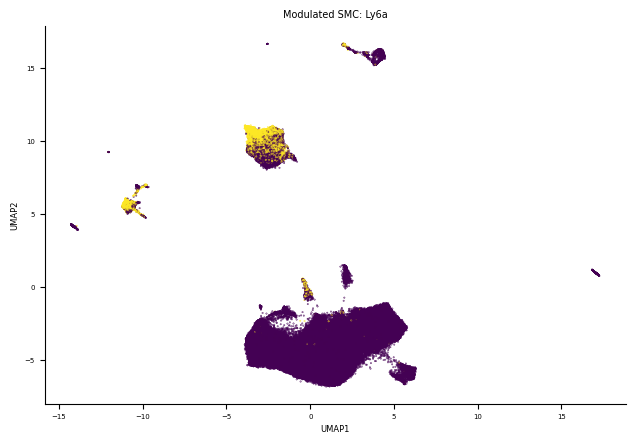

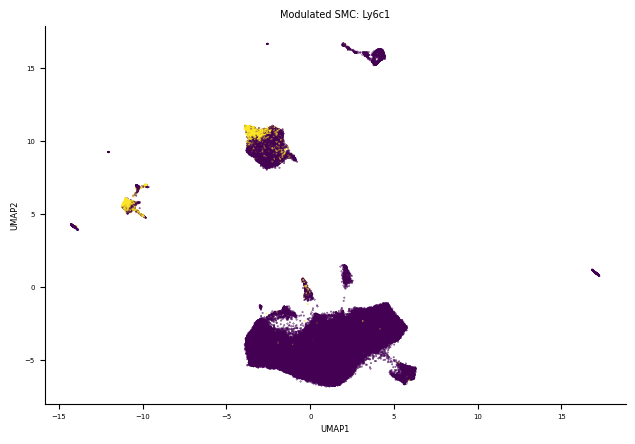

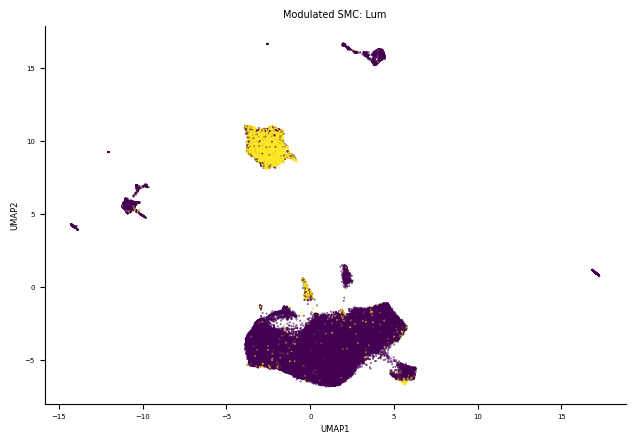

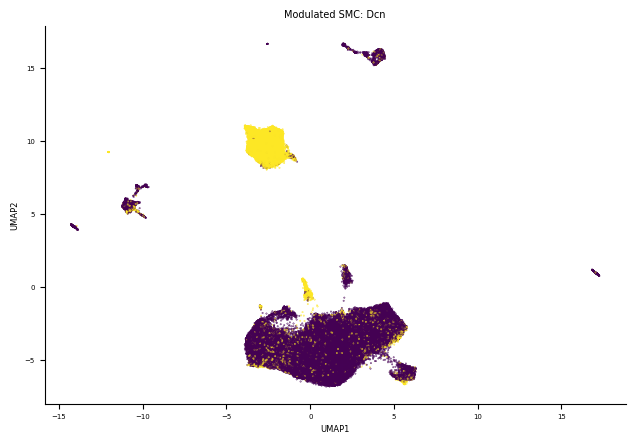

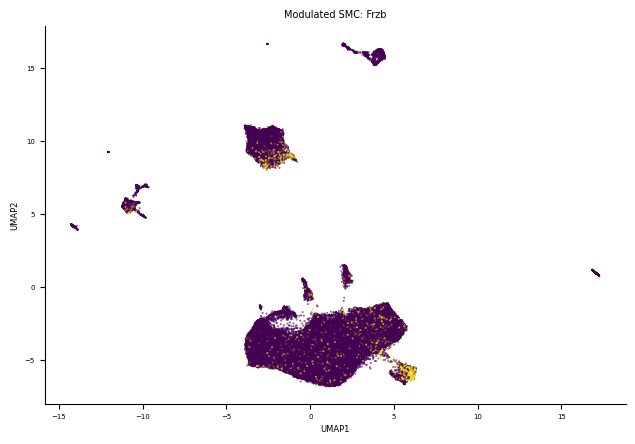

In [94]:
# --- FOR EACH OF THE CLUSTERS, 


threshold = -4

for cell_type, marker_list in marker_dict.items():
    for marker in marker_list:
        if marker not in adata.var_names:
            print("%s not in data" % marker)
            continue
        fig, axs = plt.subplots(1,1,figsize = (7.5,5),dpi=100)
        plt.scatter(adata.obsm['X_scVI_umap'][:,0],adata.obsm['X_scVI_umap'][:,1],s=0.1,c=adata[:,marker].layers['X_transformed'].flatten() >= threshold)
        plt.xlabel("UMAP1")
        plt.ylabel("UMAP2")
        plt.title("%s: %s" % (cell_type,marker))
        sns.despine()
        plt.show()




In [145]:
adata

AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'
    obsm: 'X_scVI', 'X_scVI_umap'
    layers: 'X_transformed'

In [155]:
# --- GET CELL TYPE ADATA ----



cell_types = list(marker_dict.keys())
cell_type_adatas = []
is_cell_type_mat = np.zeros((adata.shape[0],len(cell_types)))
for i,cell_type in enumerate(cell_types):
    print(cell_type)

    threshold = -3
    is_cell_type = np.sum(adata[:,marker_dict[cell_type]].layers['X_transformed'] >= threshold,axis=1) > 0
    cell_type_adata = adata[is_cell_type]
    cell_type_adatas.append(cell_type_adata)
    is_cell_type_mat[:,i] = is_cell_type
    print(cell_type_adata.shape[0])

    
print("Unlabeled")
print(np.sum(np.sum(is_cell_type_mat,axis=1) == 0))


SMC
119817
Fibroblast
18547
Endothelial
3632
Macrophage
525
T
185
Unlabeled
5498


In [55]:
# --- FOR EACH CELL TYPE, GET THE TOP UNIQUE MARKERS ---

dif_threshold = 0.5
min_log10_prop_in_cluster_of_interest = -4

# ** get the log10 prop of each gene in each cell type **
log10_prop_mat = np.zeros((len(cell_types),adata.shape[1]))
for i, cell_type_adata in enumerate(cell_type_adatas):
    log10_prop_mat[i,:] = np.array(np.sum(cell_type_adata.X,axis=0)).flatten() / np.sum(np.array(cell_type_adata.obs['lib_size']))
log10_prop_mat[log10_prop_mat <= 1e-7] = 1e-7
log10_prop_mat = np.log10(log10_prop_mat)


# ** get the unique markers **
marker_list_of_lists = []
for cell_type_index,cell_type in enumerate(cell_types):

    dif_mat = log10_prop_mat[cell_type_index,:] - np.concatenate((log10_prop_mat[:cell_type_index,:],log10_prop_mat[cell_type_index+1:,:]),axis=0)
    dif_vec = np.min(dif_mat,axis=0)

    condit_1 = dif_vec >= dif_threshold
    condit_2 = log10_prop_mat[cell_type_index,:] >= min_log10_prop_in_cluster_of_interest
    
    cell_type_candidate_markers = sorted(list(adata.var_names[condit_1 & condit_2]))
    marker_list_of_lists.append(cell_type_candidate_markers)

    print(np.sum(condit_1 & condit_2))
    
    

114
113
101
228
93


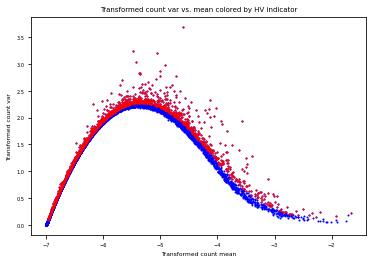

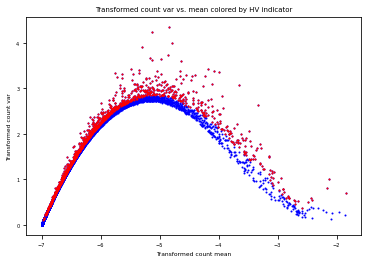

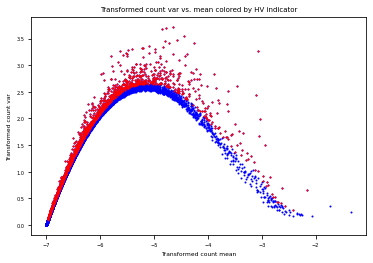

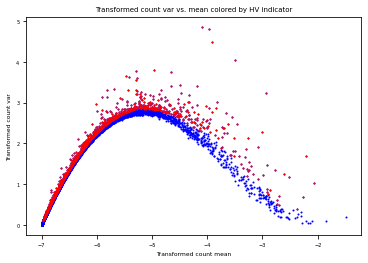

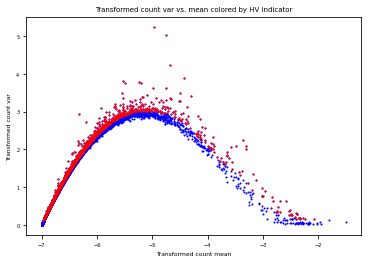

In [127]:
# --- GET HVG WITHIN EACH CELL TYPE ---

import sys
import statsmodels
from statsmodels import nonparametric
from statsmodels.nonparametric import kernel_regression


kernel_bandwidth = 0.1
std_residual_threshold = 0.5

hvg_df_list = []
for cell_type_adata in cell_type_adatas:


    # ** fit gaussian kernel to transformed counts **

    # ** get the transformed means and variances for each gene **
    X_transformed_mean = np.mean(cell_type_adata.layers['X_transformed'],axis=0)
    X_transformed_var = np.var(cell_type_adata.layers['X_transformed'],axis=0)

    # ** fit the kernel **
    model = statsmodels.nonparametric.kernel_regression.KernelReg(X_transformed_var, X_transformed_mean.reshape(-1,1), var_type = ['c'], bw = [kernel_bandwidth]) 
    pred_var,marginal_effects = model.fit()

    # ** compute the pearson residuals **
    est_std = (np.mean((X_transformed_var - pred_var)**2)) ** 0.5
    pearson_residuals = (X_transformed_var - pred_var) / est_std

    # ** get the hv gene indices **
    hv_gene_indices = np.where(pearson_residuals >= std_residual_threshold)[0]
    
    # ** get pseudobulk count **
    pseudobulk_count = np.array(np.sum(cell_type_adata.X,axis=0)).flatten()

    # ** make hv df and add to list **
    hv_df = pd.DataFrame()
    hv_df['gene'] = list(adata.var_names)
    hv_df['pseudobulk_count'] = pseudobulk_count
    hv_df['mean'] = X_transformed_mean
    hv_df['var'] = X_transformed_var
    hv_df['pearson_residual'] = pearson_residuals
    hv_df = hv_df.set_index('gene')
    hv_df = hv_df.sort_values(['pearson_residual'],ascending=False)
    hvg_df_list.append(hv_df)
    
    
    # ** viz **
    plt.clf()
    plt.scatter(X_transformed_mean,X_transformed_var,s=1,c='b')
    plt.scatter(X_transformed_mean[hv_gene_indices],X_transformed_var[hv_gene_indices],s=1,c='r')
    plt.title("Transformed count var vs. mean colored by HV indicator")
    plt.xlabel("Transformed count mean")
    plt.ylabel("Transformed count var")
    plt.show()
    





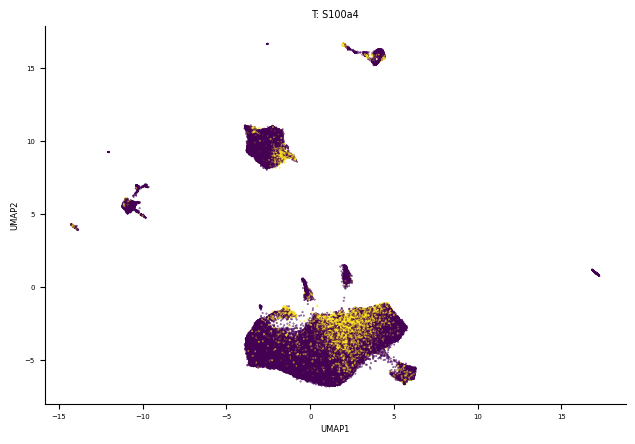

In [136]:
marker = 'S100a4'
fig, axs = plt.subplots(1,1,figsize = (7.5,5),dpi=100)
plt.scatter(adata.obsm['X_scVI_umap'][:,0],adata.obsm['X_scVI_umap'][:,1],s=0.1,c=adata[:,marker].layers['X_transformed'].flatten() >= threshold)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("%s: %s" % (cell_type,marker))
sns.despine()
plt.show()



In [171]:
# --- GET THE ACROSS CELL TYPE MARKERS ---

across_cell_type_markers = []
for l in marker_list_of_lists:
    across_cell_type_markers += l
across_cell_type_markers = sorted(list(set(across_cell_type_markers)))
len(across_cell_type_markers)


649

In [196]:
# --- GET THE WITHIN CLUSTER MARKERS ---

pearson_residual_threshold = 0.5
pseudobulk_threshold = 30 * 1e-4 * np.median(adata.obs['lib_size'])
num_top_markers_within_cluster = 100
within_cluster_markers = []
for cluster_index,cluster_df in enumerate(hvg_df_list):
    within_cluster_df = cluster_df[(cluster_df['pearson_residual'] >= pearson_residual_threshold) & (cluster_df['pseudobulk_count'] >= pseudobulk_threshold)]
    if cluster_index == 0:
        within_cluster_markers += list(within_cluster_df.index)
    else:
        within_cluster_markers += list(df_of_interest.iloc[:num_top_markers_within_cluster].index)
    print(len(within_cluster_markers))


        
        


1583
1683
1783
1883
1983


In [198]:
# --- GET THE FINAL MARKER LIST ---

final_markers = sorted(list(set(across_cell_type_markers + within_cluster_markers)))

len(final_markers)


1969

In [203]:
# --- WRITE OUT ---

folder_out = '%s/Dropbox/aorta_circadian_data/datasets/joint/data_annotations/hvg/prior_knowledge_guided' % head_folder
if not os.path.exists(folder_out):
    os.makedirs(folder_out)
fileout = '%s/hvg.txt' % folder_out
with open(fileout,"wb") as file_obj:
    file_obj.write("\n".join(final_markers).encode())


